Taavon Peoples QML Project

Data Encoding

Notes for what's next:
Add State and City into the feature map

Try to train the model with ON2 included then predict the ON2 based on the other features and see how it maps. This should be as close to the real number as possible 
We can use this to show the effectiveness of the model 
possibly compare the expected number with the real one

This try different ways to map it and compare the results (z_parameter_map, zz_parameter_map, manual designs using cnot and other gates)

For manually designed feature mapping, think about what features [data labels (white, black, etc)] are related to each other and possibly the feature that we are trying to predict

For example, add a cnot if features are related so 
-----

Change the data mapping so that grade is the label for training. Grades A & B will be +1 and Grades C & D will be -1 

NOTE: Look up compilation from Qiskit and Dr. Wang's notes, verify mapping 
Run with more records once we get it working 


Compilation is transpilation. Translating gates into native gates. 

In [1]:
# If you have not already, install scikit learn
%pip install scikit-learn
%pip install qiskit
%pip install qiskit-aer --quiet
%pip install pylatexenc
%pip install matplotlib
%pip install qiskit-ibm-runtime
%pip install qiskit-ibm-transpiler

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
from pathlib import Path
import importlib

# add project root (current working dir or nearest parent containing utils.py) to sys.path and import utils
cwd = Path.cwd().resolve()
for folder in [cwd] + list(cwd.parents):
    if (folder / "utils.py").is_file():
        sys.path.insert(0, str(folder))
        utils = importlib.import_module("utils")
        break
else:
    raise FileNotFoundError("utils.py not found in project root or any parent directory")

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
     token="yZoR4zRA8X7ZX2rauN_pkmyBrId1CJbbXR1RoN_dFvJh",
     set_as_default = True
     )

Step 1 Data Encoding
Map inputs to quantum circuit

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import init

# This only needs to be run once, as the dataset is cached after the first run
dataset = init()
# Baltimore statistics
baltimore_dataset = dataset[dataset['City'] == 'Baltimore, MD']

print(dataset["Black"][:20])

0      0
1      1
2      0
3      0
4      0
5     17
6     87
7      1
8      0
9      2
10     5
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     2
19     3
Name: Black, dtype: int64


Need to adjust the data for training
pre-processing needed here

Should adjust the data as follows for the initial test
Set each value as a percentage of the total, use that to predict the NO2 level or PM25 levels

Each Demographic is a feature here (Black, Whtie, Hispanic, etc)

In [ ]:
from itertools import count


baltimore_dataset

baltimore_dataset['Grade'].value_counts()

test_set = baltimore_dataset[baltimore_dataset['Total'] > 100 ]
test_set =  test_set[test_set['Black'] > test_set['White']]
#baltimore_dataset['Total'].value_counts().plot(kind='line')

test_set

In [6]:
print(baltimore_dataset.info())

<class 'pandas.DataFrame'>
Index: 10036 entries, 7882 to 2021377
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CUA       10036 non-null  str    
 1   City      10036 non-null  str    
 2   GEOID     10036 non-null  str    
 3   Grade     10036 non-null  str    
 4   PHOLC     10036 non-null  float64
 5   Asian     10036 non-null  int64  
 6   Black     10036 non-null  int64  
 7   Hispanic  10036 non-null  int64  
 8   White     10036 non-null  int64  
 9   Other     10036 non-null  int64  
 10  Total     10036 non-null  int64  
 11  NO2       10036 non-null  float64
 12  PM25      10036 non-null  float64
dtypes: float64(3), int64(6), str(4)
memory usage: 1.1 MB
None


In [8]:
def encode_grade(grade):
    if grade == 'A':
        return 1
    elif grade == 'B':
        return 2
    elif grade == 'C':
        return 3
    elif grade == 'D':
        return 4
    elif grade == 'F':
        return 5
    else:
        return 0
    
def convert_to_label(grade):
    if grade in ['A', 'B']:
        return 1
    else:
        return -1

In [9]:
# Format the data for the first 100 rows, to be used as input to the quantum machine learning model
#subset = baltimore_dataset.head(100)

# Use sampling to get a random subset of 1000 rows, to avoid any bias in the data
from math import pi


subset = baltimore_dataset.sample(n=1000, random_state=42)

array_stacked = np.column_stack([subset[col].values for col in ['Grade', 'White','Black', 'Hispanic', 'Asian', 'Other', 'Total', 'NO2', 'PHOLC', 'PM25']])
processed_data = list()

# Normalize the data by dividing each value by the total number of samples in that row (column 6)
# Normalize the totals by dividing by the max total in the dataset
max = np.max(array_stacked[:, 6])
for row in array_stacked:
    processed_data.append(np.array([
                           (row[1] / row[6]) * 2 * pi, # % of White population
                           (row[2] / row[6]) * 2 * pi, # % of Black population
                           (row[3] / row[6]) * 2 * pi, # % of Hispanic population
                           (row[4] / row[6]) * 2 * pi, # % of Asian population
                           (row[5] / row[6]) * 2 * pi, # % of Other population
                           row[6] / max,     # Normalized total
                           row[7],           # NO2 levels | Low is good
                           row[8],           # PHOLC levels
                           row[9],          # PM25 levels | high is bad
                           convert_to_label(row[0])]))  # Grade is encoded as a label, where A and B are 1 (good) and C, D, F are -1 (bad)          
processed_data = np.array(processed_data)


                                         

print(processed_data) 

[[ 6.16997476  0.          0.         ...  1.         11.6495
  -1.        ]
 [ 0.          6.28318531  0.         ...  0.98758611 11.4141
  -1.        ]
 [ 0.16249617  5.90402757  0.21666156 ...  1.         10.2635
   1.        ]
 ...
 [ 4.1887902   2.0943951   0.         ...  1.         11.4272
  -1.        ]
 [ 5.26429039  1.01889491  0.         ...  1.         10.5167
   1.        ]
 [ 1.7951958   4.48798951  0.         ...  1.         11.2705
   1.        ]]


circuit depth =  53


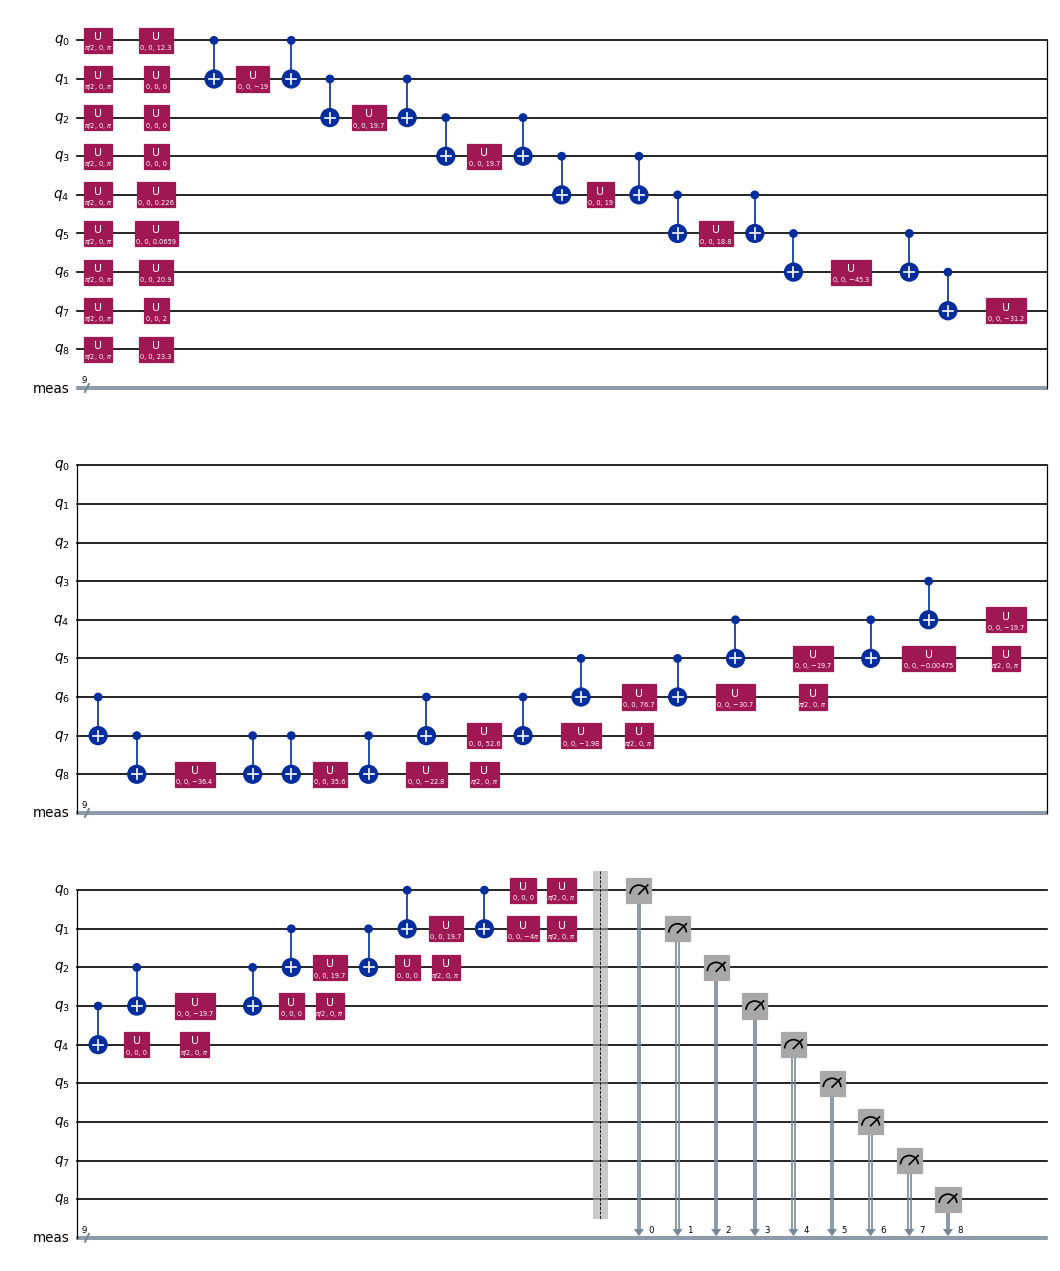

In [12]:
# Sample with two rows


from qiskit.circuit.library import z_feature_map, zz_feature_map
from qiskit.circuit.library import unitary_overlap

# Data points with labels removed, for inner product
#train_data = [dataset["Black"][:10], dataset["White"][:10]]
train_data=[processed_data[0][:-1], processed_data[1][:-1]]

# Encode the data into quantum states using the ZFeatureMap
#fm = z_feature_map(feature_dimension=np.shape(train_data)[1])
fm = zz_feature_map(feature_dimension=np.shape(train_data)[1], entanglement='linear', reps=1)

num_qubits = fm.num_qubits

#Assign Params
unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

Create Ansatz to show data relationships. 

Think about how the values are related

4
2+ qubit depth: 2


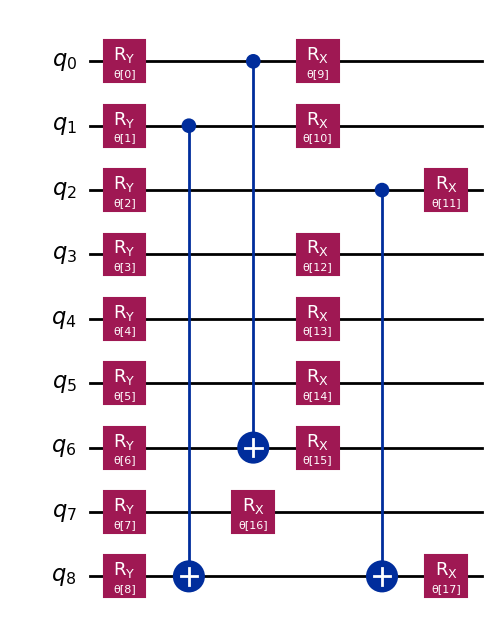

In [ ]:
# Import the necessary packages
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(num_qubits)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * num_qubits)

# A first variational layer:
for i in range(num_qubits):
    qnn_circuit.ry(params[i], i)

# Here is a list of qubit pairs between which we want CNOT gates. The choice of these is not yet obvious.
# Change this to include ALL of the demographic group qubits 
#qnn_cnot_list = [[0, 1], [1, 2], [2, 3], [3, 4]]
qnn_cnot_list = [[0, 6],[1, 8]]

'''
    # % of White population
    # % of Black population
    # % of Hispanic population
    # % of Asian population
    # % of Other population
    # Normalized total
    # NO2 levels | Low is good
    # PHOLC levels
    # PM25 levels | high is bad
'''

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(num_qubits):
    qnn_circuit.rx(params[num_qubits + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Draw the circuit
qnn_circuit.draw("mpl")

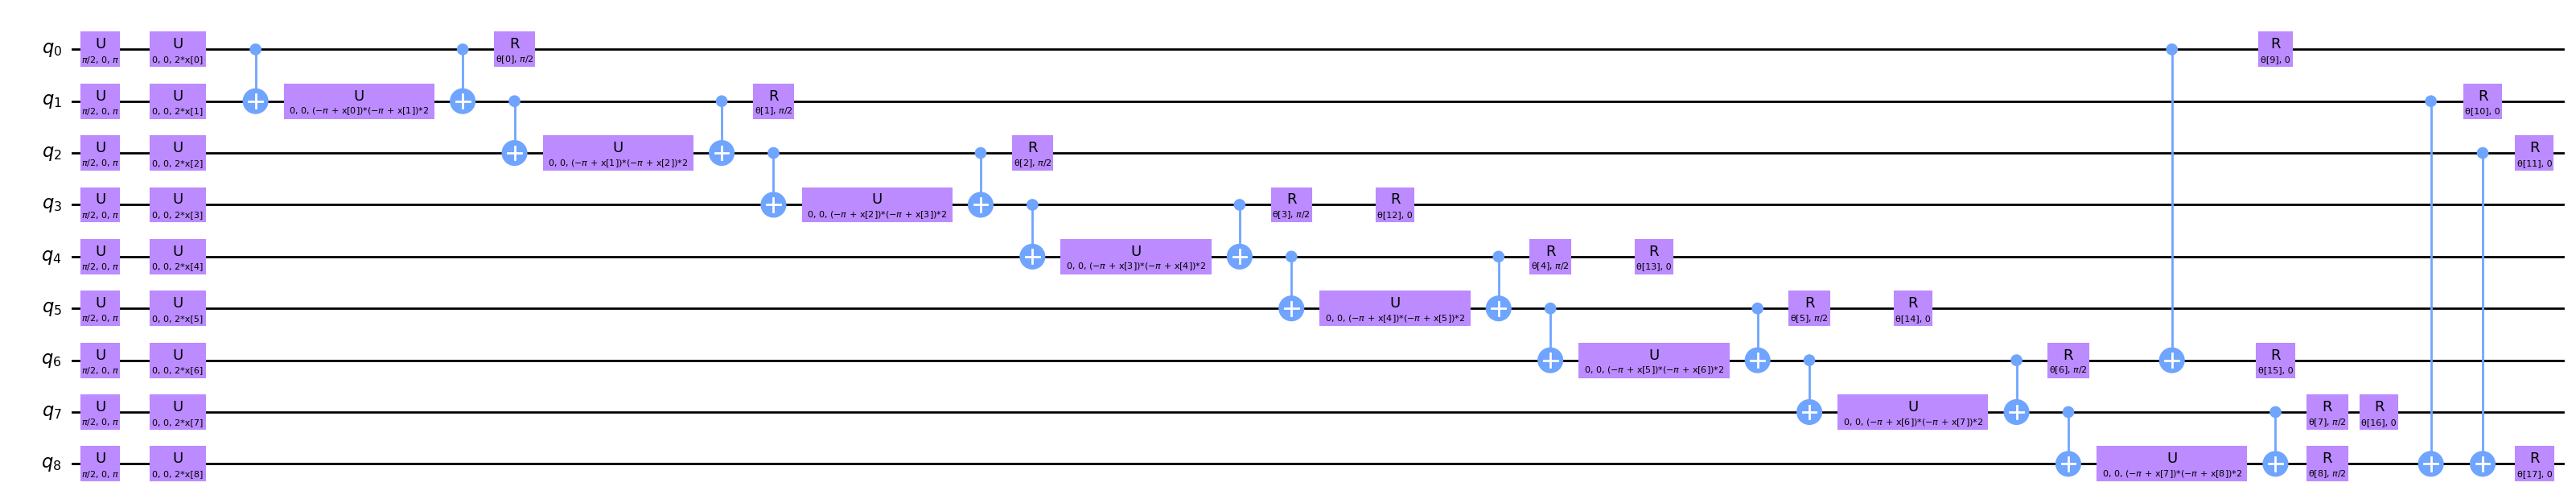

In [14]:
# QNN ansatz
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(fm, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

In [ ]:
array_without_last_col = processed_data[:3, :-1]

print(array_without_last_col)

In [15]:
# Training with more data

train_size = 750
X_train = processed_data[0:train_size, :-1]
# The last column of the dataset contains the labels, so we take that for training labels
train_labels = processed_data[0:train_size, -1]
#X_train = processed_data[0:train_size]

# Prepare testing data
test_size = 250
X_test = processed_data[train_size : train_size + test_size, :-1]
#X_test = processed_data[train_size : train_size + test_size]
test_labels = processed_data[train_size : train_size + test_size, -1]

# Empty kernel matrix
# These matrices are NOT NEEDED anymore
num_samples = np.shape(X_train)[0]
#kernel_matrix = np.full((num_samples, num_samples), np.nan)
#test_matrix = np.full((test_size, num_samples), np.nan)



Step 2
Optimize the circuit for execution

In [16]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend
service = QiskitRuntimeService()
backend = service.least_busy(
    # NOTE: Using Simulator for testing, for speed
    operational=True, simulator=False, min_num_qubits=num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-04-12 18:27:53,493: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (pay-as-you-go, open), the available account instances are: open-instance, paid-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-12 18:27:55,182: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-12 18:27:56,361: Loading instance: paid-instance, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-04-12 18:27:58,597: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


Transpilation STEPS (Compiling gates into native gates)

In [17]:
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target

pm = generate_preset_pass_manager(target=target, optimization_level=3)
pm.scheduling = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        ConstrainedReschedule(
            acquire_alignment=target.acquire_alignment,
            pulse_alignment=target.pulse_alignment,
            target=target,
        ),
        PadDynamicalDecoupling(
            target=target,
            dd_sequence=[XGate(), XGate()],
            pulse_alignment=target.pulse_alignment,
        ),
    ]
)

In [18]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])

In [19]:
# Try pass manager several times, since heuristics can return various transpilations on large circuits, and we want the shallowest.

transpiled_qcs = []
transpiled_depths = []
transpiled_2q_depths = []
for i in range(1, 10):
    circuit_ibm = pm.run(full_circuit)
    transpiled_qcs.append(circuit_ibm)
    transpiled_depths.append(circuit_ibm.decompose().depth())
    transpiled_2q_depths.append(
        circuit_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)
    )
    # print(i)

print(transpiled_depths)
print(transpiled_2q_depths)

# Use the shallowest

minpos = transpiled_2q_depths.index(min(transpiled_2q_depths))

[269, 283, 261, 262, 265, 296, 262, 261, 262]
[36, 39, 33, 33, 33, 41, 33, 33, 33]


In [20]:
circuit_ibm = transpiled_qcs[minpos]
observable_ibm = observable.apply_layout(circuit_ibm.layout)
print(circuit_ibm.decompose().depth())
print(
    f"2+ qubit depth: {circuit_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

261
2+ qubit depth: 33


In [ ]:
# DO NOT RUN THIS CELL ANYMORE | OLD VERSION
# Apply level 3 optimization to our overlap circuit
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

print("circuit depth = ", overlap_ibm.decompose().depth())
overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)

circuit depth =  264


31

Step 3: Execute the circuit

In [ ]:
# Run this for a simulator
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Options, Session, Sampler

num_shots = 1000

# Evaluate the problem using state vector-based primitives from Qiskit
sampler = StatevectorSampler()
results = sampler.run([overlap_circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

The cell below is  for real QC execution. Create methods for this 

In [50]:
# Benchmarked on an Eagle processor, 7-11-24, took 4 sec.
#this is to execure on a real machine
# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

num_shots = 10000

# Use sampler and get the counts

sampler = Sampler(mode=backend)
#this one is using the overlap_ibm circuit instead of overlap_circ
results = sampler.run([overlap_ibm], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

Convert answer back to classical by reading the 0 bit

This Methods are just helpers for Kernel tests. All optional 

In [15]:
counts.get(0, 0.0) / num_shots



0.0

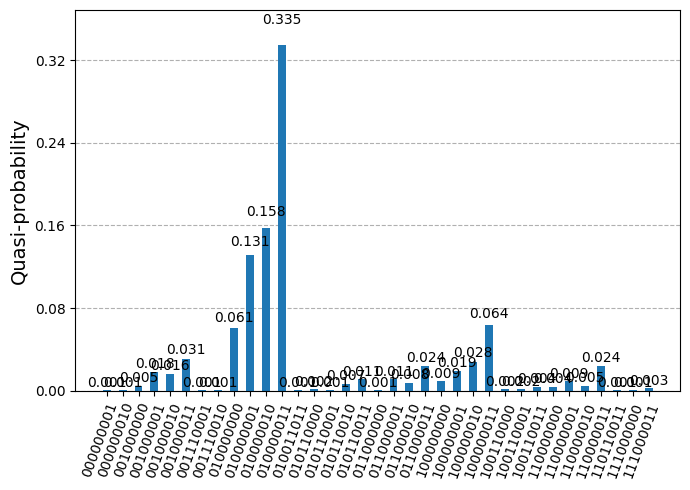

In [16]:
from qiskit.visualization import plot_distribution

plot_distribution(counts_bit)


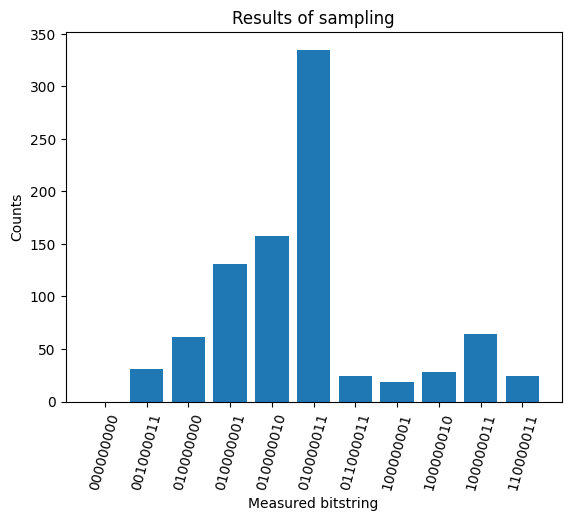

In [17]:
def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()


visualize_counts(counts, overlap_circ.num_qubits)

QNN Code continued 

In [18]:
from qiskit.primitives import BaseEstimatorV2
from qiskit.quantum_info.operators.base_operator import BaseOperator


def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

Define a loss function

In [19]:
def mse_loss(predict: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Mean squared error (MSE).

    prediction: predictions from the forward pass of neural network.
    target: true labels.

    output: MSE loss.
    """
    if len(predict.shape) <= 1:
        return ((predict - target) ** 2).mean()
    else:
        raise AssertionError("input should be 1d-array")
    


In [20]:
def mse_loss_weights(weight_params: np.ndarray) -> np.ndarray:
    """
    Cost function for the optimizer to update the ansatz parameters.

    weight_params: ansatz parameters to be updated by the optimizer.

    output: MSE loss.
    """
    predictions = forward(
        circuit=circuit,
        input_params=input_params,
        weight_params=weight_params,
        estimator=estimator,
        observable=observable,
    )

    cost = mse_loss(predict=predictions, target=target)
    objective_func_vals.append(cost)

    global iter
    if iter % 50 == 0:
        print(f"Iter: {iter}, loss: {cost}")
    iter += 1

    return cost

In [21]:
from scipy.optimize import minimize

Initial Global Variables

In [22]:
# Globals
circuit = full_circuit
observables = observable
# input_params = train_images_batch
# target = train_labels_batch
objective_func_vals = []
iter = 0

STEP 3: Execute Primities

In [ ]:
from qiskit.primitives import StatevectorEstimator as Estimator

batch_size = 100
num_epochs = 1
num_samples = len(X_train)

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)

# This should not be random, changes this
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi
#weight_params = np.full(len(ansatz.parameters), 0.5) * 2 * np.pi
'''
    # % of White population
    # % of Black population
    # % of Hispanic population
    # % of Asian population
    # % of Other population
    # Normalized total
    # NO2 levels | Low is good
    # PHOLC levels
    # PM25 levels | high is bad
'''

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_data_batch = np.array(X_train[start_i:end_i])
        train_labels_batch = np.array(train_labels[start_i:end_i])
        input_params = train_data_batch
        target = train_labels_batch
        iter = 0
        res = minimize(
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
        )
        weight_params = res["x"]

NameError: name 'X_train' is not defined

In [26]:
import copy
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
# from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

estimator = Estimator()
# estimator = Estimator(backend=backend)

pred_train = forward(circuit, np.array(X_train), res["x"], estimator, observable)

print(pred_train)

pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] = 1
pred_train_labels[pred_train_labels < 0] = -1
print(pred_train_labels)
print(train_labels)

accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Train accuracy: {accuracy * 100}%")

[ 2.53947536e-02  4.78170530e-02  4.61455036e-02 -1.74228332e-02
  3.47444337e-02 -2.64726532e-01 -4.59694060e-02 -1.61244682e-02
 -3.61277448e-02 -4.91109634e-04 -2.20119627e-01 -6.98653159e-02
  2.71599290e-01  1.65167063e-01 -3.21853638e-01 -6.11246139e-03
 -4.07427706e-02 -2.96474617e-02  3.50028721e-01 -1.63161746e-01
  1.53290434e-01  3.25600711e-02  4.21656598e-01 -1.63391304e-02
 -5.63627133e-02 -1.44811538e-01 -3.44009814e-01  3.76896190e-02
 -2.75664319e-01  8.78008829e-03  3.14754441e-02 -5.98389295e-01
  1.35459218e-02  7.33837109e-02 -1.55661452e-01 -3.07391487e-01
  1.14558246e-01  3.18224221e-02 -1.09864115e-01  5.29157153e-02
 -1.51336127e-02  2.79544096e-01 -1.52185531e-01 -3.23886698e-01
 -1.44074442e-02 -1.07220738e-01  1.20109878e-02 -6.01012562e-02
 -1.38817507e-01 -9.37171408e-02 -2.32845188e-02 -2.79748196e-01
 -5.70870068e-01 -1.71367445e-01  7.25899502e-02  3.34834421e-01
  1.56472596e-02 -2.12202572e-02  1.95737328e-02 -1.60937439e-04
 -9.98328120e-02 -3.12387